In [1]:
import pandas as pd
import zipfile

In [2]:
zf = zipfile.ZipFile('gtfs_fp2026_20260314.zip')

In [4]:
# Chargement des fichiers clés
stops = pd.read_csv(zf.open('stops.txt'))
routes = pd.read_csv(zf.open('routes.txt'))
stop_times = pd.read_csv(zf.open('stop_times.txt'))
trips = pd.read_csv(zf.open('trips.txt'))

/var/folders/dg/jjw_9gyd1p38f4_jp_6s89r00000gn/T/ipykernel_57546/3349198966.py:2: DtypeWarning: Columns (5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  stops = pd.read_csv(zf.open('stops.txt'))


In [26]:
stops.head()

,stop_id,stop_name,stop_lat,stop_lon,location_type,parent_station,platform_code,original_stop_id
0,1100008,"Zell (Wiesental), Wilder Mann",47.710084,7.859648,NaN,Parent1100008,NaN,ch:1:sloid:1100008
1,1100009,"Zell (Wiesental), Grönland",47.713191,7.862909,NaN,Parent1100009,NaN,ch:1:sloid:1100009
2,1100010,Atzenbach,47.714618,7.872350,NaN,Parent1100010,NaN,ch:1:sloid:1100010
3,1100011,"Mambach, Brücke",47.728209,7.877470,NaN,Parent1100011,NaN,ch:1:sloid:1100011
4,1100012,"Mambach, Mühlschau",47.734082,7.881387,NaN,Parent1100012,NaN,ch:1:sloid:1100012


In [27]:
routes.head()

,route_id,agency_id,route_short_name,route_long_name,route_desc,route_type
0,91-10-A-j26-1,78,S10,NaN,S,109
1,91-10-B-j26-1,11,S10,NaN,S,109
2,91-10-C-j26-1,65,S10,NaN,S,109
3,91-10-D-j26-1,11,10,NaN,EXT,117
4,91-10-E-j26-1,3849,10,NaN,T,900


In [28]:
stop_times.head()

,trip_id,arrival_time,departure_time,stop_id,stop_sequence,pickup_type,drop_off_type,departure_hour
0,1.TA.91-10-A-j26-1.1.H,18:07:00,18:07:00,8503054:0:1,1,0,0,18
1,1.TA.91-10-A-j26-1.1.H,18:08:00,18:08:00,8503053:0:1,2,0,0,18
2,1.TA.91-10-A-j26-1.1.H,18:09:00,18:09:00,8503052:0:1,3,0,0,18
3,1.TA.91-10-A-j26-1.1.H,18:12:00,18:12:00,8503051:0:1,4,0,0,18
4,1.TA.91-10-A-j26-1.1.H,18:15:00,18:15:00,8503090:0:1,5,0,0,18


In [29]:
trips.head()

,route_id,service_id,trip_id,trip_headsign,trip_short_name,direction_id,block_id,original_trip_id,hints
0,91-10-A-j26-1,TA+lbs00,1.TA.91-10-A-j26-1.1.H,Zürich HB,12902,0,NaN,ch:1:sjyid:100058:12902-001,2 NF VN
1,91-10-A-j26-1,TA+lbs00,10.TA.91-10-A-j26-1.1.H,Zürich HB,12774,0,NaN,ch:1:sjyid:100058:12774-001,2 NF VN
2,91-10-A-j26-1,TA+ral00,100.TA.91-10-A-j26-1.5.H,Zürich Selnau,12808,0,NaN,ch:1:sjyid:100058:12808-002,2 NF
3,91-10-A-j26-1,TA+ral00,101.TA.91-10-A-j26-1.5.H,Zürich Selnau,12916,0,NaN,ch:1:sjyid:100058:12916-002,2 NF
4,91-10-A-j26-1,TA+ral00,102.TA.91-10-A-j26-1.5.H,Zürich Selnau,12920,0,NaN,ch:1:sjyid:100058:12920-003,2 NF


In [5]:
print(f"Nombre d'arrêts en Suisse : {len(stops)}")
print(f"Nombre de lignes de transport : {len(routes)}")

Nombre d'arrêts en Suisse : 96949
Nombre de lignes de transport : 4840


In [32]:
# Dictionnaire basé sur la liste officielle (Codes GTFS -> Label Anglais)
swiss_gtfs_mapping = {
    1303: "Lift / Elevator",
    700: "Bus",
    710: "Panorama Bus",
    202: "National long-distance bus",
    201: "International long-distance bus",
    702: "Express bus",
    705: "Night Bus",
    715: "On-demand Bus",
    1500: "Taxi",
    1300: "Cableway / Gondola",
    116: "Rack-railroad",
    401: "Metro",
    1400: "Funicular",
    1000: "Ship / Boat",
    900: "Tram",
    1100: "Airplane",
    1700: "Unknown mode",
    117: "Special Train",
    104: "Car-carrying / Tunnel Train",
    103: "Semi fast Train / InterRegio",
    102: "High-speed / InterCity Train",
    105: "Night Train",
    101: "International High-speed Train",
    100: "Regional / Generic Train",
    107: "Panorama Express",
    106: "Regional / RegioExpress",
    109: "Urban Train / S-Bahn"
}

# Application au dataframe routes
routes['mode'] = routes['route_type'].map(swiss_gtfs_mapping).fillna("Other / Unknown")

# Vérification de la distribution
mode_summary = routes['mode'].value_counts()
print("Distribution of transportation modes (English labels):")
print(mode_summary)

Distribution of transportation modes (English labels):
mode
Bus                               3202
Regional / RegioExpress            377
Cableway / Gondola                 290
Night Bus                          216
Urban Train / S-Bahn               203
Ship / Boat                        103
Special Train                       84
On-demand Bus                       77
Funicular                           53
Tram                                49
Semi fast Train / InterRegio        46
High-speed / InterCity Train        46
International High-speed Train      45
Express bus                         12
Rack-railroad                       12
Panorama Express                    10
Night Train                          4
Taxi                                 4
Metro                                2
Panorama Bus                         2
Lift / Elevator                      2
National long-distance bus           1
Name: count, dtype: int64


In [33]:
routes.head()

,route_id,agency_id,route_short_name,route_long_name,route_desc,route_type,mode_en,mode
0,91-10-A-j26-1,78,S10,NaN,S,109,Urban Train / S-Bahn,Urban Train / S-Bahn
1,91-10-B-j26-1,11,S10,NaN,S,109,Urban Train / S-Bahn,Urban Train / S-Bahn
2,91-10-C-j26-1,65,S10,NaN,S,109,Urban Train / S-Bahn,Urban Train / S-Bahn
3,91-10-D-j26-1,11,10,NaN,EXT,117,Special Train,Special Train
4,91-10-E-j26-1,3849,10,NaN,T,900,Tram,Tram


In [6]:
# On cherche les routes de type 'InterCity' ou 'IC'
# Note: route_type 100/102 correspond souvent aux trains longue distance dans le standard suisse
ic_routes = routes[routes['route_short_name'].str.contains('IC', na=False)]
ic_trips = trips[trips['route_id'].isin(ic_routes['route_id'])]

# Récupérer les stop_id où les IC s'arrêtent effectivement
ic_stop_ids = stop_times[stop_times['trip_id'].isin(ic_trips['trip_id'])]['stop_id'].unique()
ic_stops = stops[stops['stop_id'].isin(ic_stop_ids)]

print(f"Nombre de gares IC identifiées : {len(ic_stops)}")
ic_stops.head()

Nombre de gares IC identifiées : 433


,stop_id,stop_name,stop_lat,stop_lon,location_type,parent_station,platform_code,original_stop_id
8590,8014325,Ringsheim/Europa-Park,48.248725,7.773041,NaN,Parent8014325,NaN,8014325
8628,8014350,Freiburg(Breisgau) Hbf,47.997699,7.841170,NaN,Parent8014350,NaN,8014350
8810,8014558,Singen (Hohentwiel),47.758878,8.841273,NaN,Parent8014558,NaN,8014558
9256,8301003,Domodossola (I),46.115291,8.296238,NaN,Parent8301003,NaN,8301003
9308,8500010,Basel SBB,47.547413,7.589560,NaN,Parent8500010,NaN,ch:1:sloid:10


In [25]:
# Conversion simple des stop_times en format numérique pour filtrer
def to_seconds(t):
    h, m, s = map(int, t.split(':'))
    return h * 3600 + m * 60 + s

# Filtre sur l'heure de pointe (7h-9h -> 25200s à 32400s)
rush_hour = stop_times[(stop_times['arrival_time'].apply(to_seconds) >= 25200) & 
                       (stop_times['arrival_time'].apply(to_seconds) <= 32400)]

# Nombre de passages par arrêt pendant l'heure de pointe
stop_frequency = rush_hour.groupby('stop_id').size().reset_index(name='frequence')
stops_with_freq = stops.merge(stop_frequency, on='stop_id', how='left').fillna(0)

# Top 10 des arrêts les plus actifs
stops_with_freq.sort_values(by='frequence', ascending=False)[['stop_name', 'frequence']].head(10)

,stop_name,frequence
15724,"Schwyz, Zentrum",4419.0
37160,"Schwyz, Steisteg",2446.0
37157,"Ibach, Mythen Center",2426.0
15730,"Brunnen, Bahnhof",2224.0
15723,"Schwyz, Zentrum",2176.0
50671,"Ostermundigen, Rüti",1873.0
59644,"Schliern, Bus-Endstation",1853.0
37159,"Schwyz, Lücken",1846.0
37158,"Ibach, Mythen Center",1846.0
48479,"Seewen SZ, Seewen Markt",1792.0


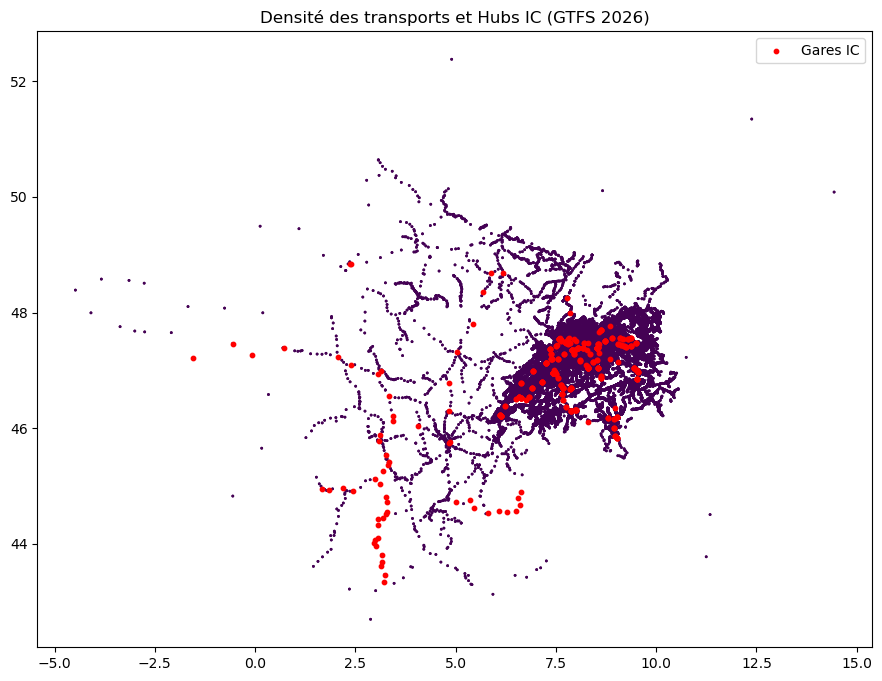

In [22]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Conversion en GeoDataFrame (WGS84)
gdf_stops = gpd.GeoDataFrame(
    stops_with_freq, 
    geometry=gpd.points_from_xy(stops_with_freq.stop_lon, stops_with_freq.stop_lat),
    crs="EPSG:4326"
)

# Plot simple de la densité des arrêts colorés par fréquence
fig, ax = plt.subplots(figsize=(12, 8))
gdf_stops.plot(ax=ax, column='frequence', markersize=1, cmap='viridis')
ic_stops_gdf = gdf_stops[gdf_stops['stop_id'].isin(ic_stop_ids)]
ic_stops_gdf.plot(ax=ax, color='red', markersize=10, label='Gares IC') # Hubs en rouge

plt.title("Densité des transports et Hubs IC (GTFS 2026)")
plt.legend()
plt.show()

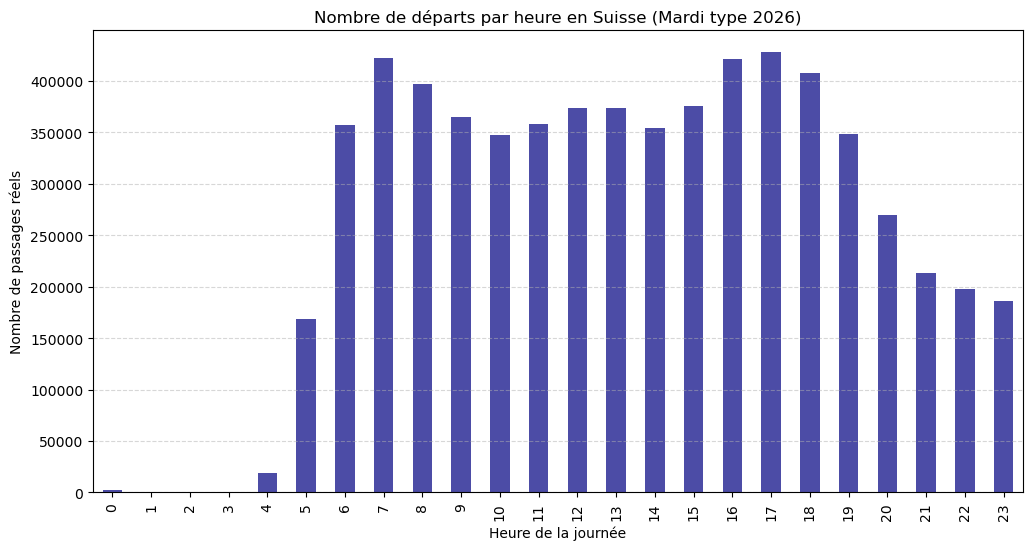

Total des départs à 8h : 397,119


In [34]:
# 1. Charger le calendrier pour identifier les services d'un jour de semaine (ex: Mardi)
calendar = pd.read_csv(zf.open('calendar.txt'))

# On ne garde que les services qui tournent le mardi ('tuesday' == 1)
tuesday_services = calendar[calendar['tuesday'] == 1]['service_id']

# 2. Filtrer les trips pour ne garder que ceux du mardi
tuesday_trips = trips[trips['service_id'].isin(tuesday_services)]['trip_id']

# 3. Filtrer les stop_times pour ne garder que ces trips
st_tuesday = stop_times[stop_times['trip_id'].isin(tuesday_trips)].copy()

# 4. Refaire l'extraction de l'heure et le groupement
st_tuesday['departure_hour'] = st_tuesday['departure_time'].str.split(':').str[0].astype(int)

# On filtre les heures aberrantes (parfois le GTFS note 25:00 pour les trajets après minuit)
st_tuesday = st_tuesday[st_tuesday['departure_hour'] < 24]

hourly_activity_fixed = st_tuesday.groupby('departure_hour').size()

# Visualisation
plt.figure(figsize=(12, 6))
hourly_activity_fixed.plot(kind='bar', color='navy', alpha=0.7)
plt.title("Nombre de départs par heure en Suisse (Mardi type 2026)")
plt.xlabel("Heure de la journée")
plt.ylabel("Nombre de passages réels")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

print(f"Total des départs à 8h : {hourly_activity_fixed.get(8, 0):,}")

In [24]:
# 1. On se concentre sur une fenêtre représentative (ex: 07h00 - 09h00)
# C'est l'heure où l'accessibilité est la plus critique pour les travailleurs/étudiants
morning_rush = stop_times[(stop_times['departure_hour'] >= 7) & (stop_times['departure_hour'] < 9)]

# 2. Compter le nombre de passages par arrêt pendant ces 2 heures
service_density = morning_rush.groupby('stop_id').size().reset_index(name='nb_passages')

# 3. Fusionner avec les coordonnées géographiques des arrêts
stops_service = stops.merge(service_density, on='stop_id', how='left').fillna(0)

# 4. Créer une colonne de score simple (Passages par heure)
stops_service['service_index'] = stops_service['nb_passages'] / 2

print("Aperçu des arrêts avec leur intensité de service :")
print(stops_service[['stop_name', 'service_index']].sort_values(by='service_index', ascending=False).head(10))

Aperçu des arrêts avec leur intensité de service :
                      stop_name  service_index
15724           Schwyz, Zentrum         2209.5
37157      Ibach, Mythen Center         1157.0
37160          Schwyz, Steisteg         1157.0
15730          Brunnen, Bahnhof         1112.0
15723           Schwyz, Zentrum         1088.0
50671       Ostermundigen, Rüti          926.5
59644  Schliern, Bus-Endstation          926.5
37159            Schwyz, Lücken          923.0
37158      Ibach, Mythen Center          923.0
48479   Seewen SZ, Seewen Markt          896.0
